## 1. Setup & Library Installation

In [1]:
!pip install -q shap lime xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn
!pip install -q imbalanced-learn
!pip install -q pdpbox

import warnings
warnings.filterwarnings('ignore')

print("All libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 8.2 MB/s eta 0:00:00
All libraries installed successfully!


## 2. Import Libraries

In [3]:
import pandas as pd
import numpy as np
from io import StringIO

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc
)

import shap
import lime
import lime.lime_tabular
from sklearn.inspection import permutation_importance, partial_dependence

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

print("All imports successful!")

All imports successful!


## 3. Load Data

In [4]:
df = pd.read_csv('/content/cardiovascular_diseases_processed .csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (68783, 12)

First few rows:
   AGE  GENDER  HEIGHT  WEIGHT  AP_HIGH  AP_LOW  CHOLESTEROL  GLUCOSE  SMOKE  \
0   50       2     168      62      110      80            1        1      0   
1   55       1     156      85      140      90            3        1      0   
2   52       1     165      64      130      70            3        1      0   
3   48       2     169      82      150     100            1        1      0   
4   48       1     156      56      100      60            1        1      0   

   ALCOHOL  PHYSICAL_ACTIVITY  CARDIO_DISEASE  
0        0                  1               0  
1        0                  1               1  
2        0                  0               1  
3        0                  1               1  
4        0                  0               0  

Data types:
AGE                  int64
GENDER               int64
HEIGHT               int64
WEIGHT               int64
AP_HIGH              int64
AP_LOW               int64
CHOLESTEROL 

## 4. Exploratory Data Analysis (EDA)

In [5]:
print("="*80)
print("STATISTICAL SUMMARY")
print("="*80)
print(df.describe())

print("\n" + "="*80)
print("CLASS DISTRIBUTION")
print("="*80)
print(df['CARDIO_DISEASE'].value_counts())
print(f"\nClass Balance Ratio:")
print(df['CARDIO_DISEASE'].value_counts(normalize=True))

STATISTICAL SUMMARY
                AGE        GENDER        HEIGHT        WEIGHT       AP_HIGH  \
count  68783.000000  68783.000000  68783.000000  68783.000000  68783.000000   
mean      53.326781      1.348749    164.361252     74.121934    126.614585   
std        6.768163      0.476578      8.184850     14.331392     16.763763   
min       30.000000      1.000000     55.000000     11.000000     60.000000   
25%       48.000000      1.000000    159.000000     65.000000    120.000000   
50%       54.000000      1.000000    165.000000     72.000000    120.000000   
75%       58.000000      2.000000    170.000000     82.000000    140.000000   
max       65.000000      2.000000    250.000000    200.000000    240.000000   

             AP_LOW   CHOLESTEROL       GLUCOSE         SMOKE       ALCOHOL  \
count  68783.000000  68783.000000  68783.000000  68783.000000  68783.000000   
mean      81.381591      1.364727      1.225986      0.088001      0.053632   
std        9.676679      0.6789

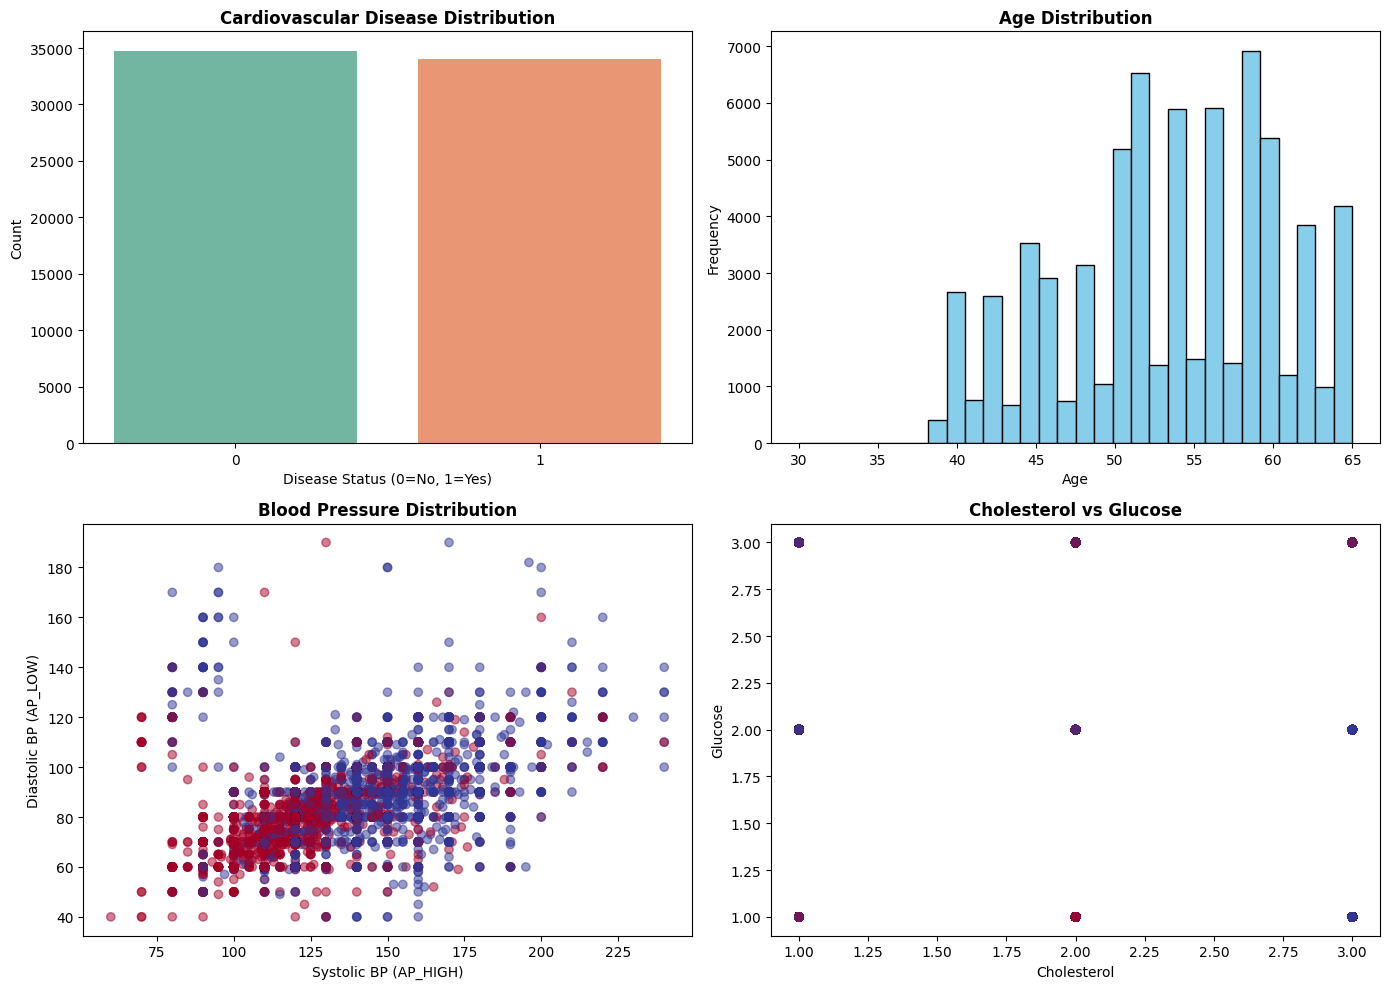

EDA visualizations saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='CARDIO_DISEASE', data=df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Cardiovascular Disease Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Disease Status (0=No, 1=Yes)')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(df['AGE'], bins=30, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].scatter(df['AP_HIGH'], df['AP_LOW'], alpha=0.5, c=df['CARDIO_DISEASE'], cmap='RdYlBu')
axes[1, 0].set_title('Blood Pressure Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Systolic BP (AP_HIGH)')
axes[1, 0].set_ylabel('Diastolic BP (AP_LOW)')

axes[1, 1].scatter(df['CHOLESTEROL'], df['GLUCOSE'], alpha=0.5, c=df['CARDIO_DISEASE'], cmap='RdYlBu')
axes[1, 1].set_title('Cholesterol vs Glucose', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cholesterol')
axes[1, 1].set_ylabel('Glucose')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print("EDA visualizations saved!")

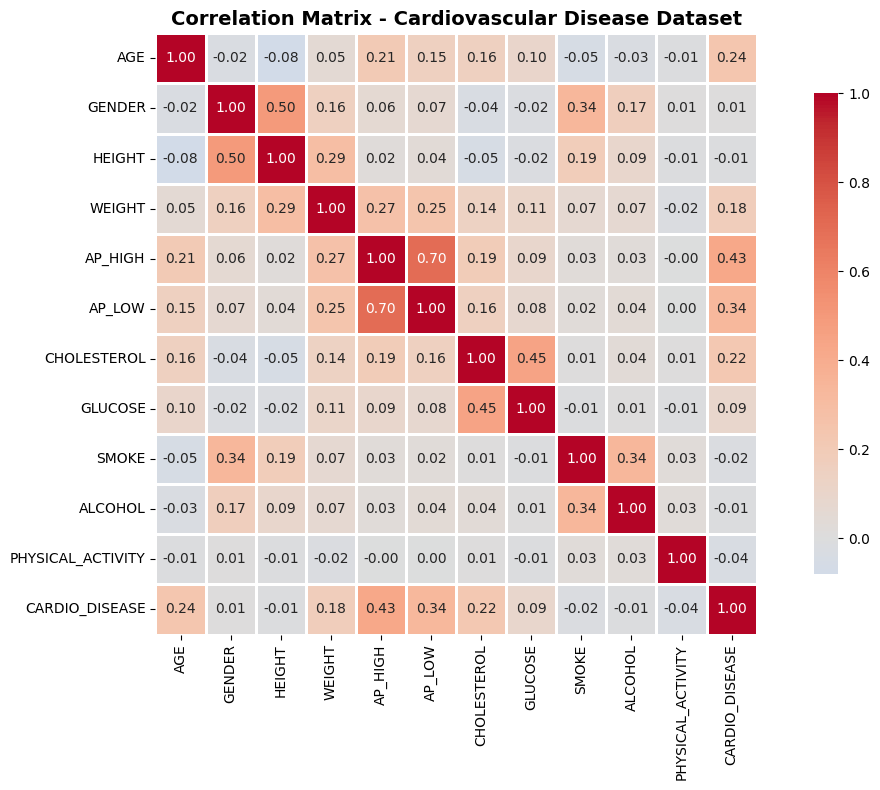


FEATURE CORRELATIONS WITH TARGET (CARDIO_DISEASE)
CARDIO_DISEASE       1.000000
AP_HIGH              0.425109
AP_LOW               0.335067
AGE                  0.239133
CHOLESTEROL          0.221517
WEIGHT               0.179680
GLUCOSE              0.090100
GENDER               0.007214
ALCOHOL             -0.008222
HEIGHT              -0.010752
SMOKE               -0.016285
PHYSICAL_ACTIVITY   -0.037197
Name: CARDIO_DISEASE, dtype: float64


In [7]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Cardiovascular Disease Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("FEATURE CORRELATIONS WITH TARGET (CARDIO_DISEASE)")
print("="*80)
correlations_with_target = df.corr()['CARDIO_DISEASE'].sort_values(ascending=False)
print(correlations_with_target)

## 5. Data Preprocessing & Feature Engineering

In [8]:
X = df.drop('CARDIO_DISEASE', axis=1)
y = df['CARDIO_DISEASE']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"\nMissing values in features: {X.isnull().sum().sum()}")
print(f"Missing values in target: {y.isnull().sum()}")

X = X.fillna(X.mean())

print("\n Missing values handled!")

Features shape: (68783, 11)
Target shape: (68783,)

Missing values in features: 0
Missing values in target: 0

 Missing values handled!


In [9]:
X['BMI'] = X['WEIGHT'] / ((X['HEIGHT'] / 100) ** 2)
X['BP_RATIO'] = X['AP_HIGH'] / (X['AP_LOW'] + 1)
X['PULSE_PRESSURE'] = X['AP_HIGH'] - X['AP_LOW']
X['AGE_BMI_INTERACTION'] = X['AGE'] * X['BMI']
X['BP_CHOL_INTERACTION'] = X['AP_HIGH'] * X['CHOLESTEROL']

print(f"New feature set shape: {X.shape}")
print(f"\nNew features added:")
print(X[['BMI', 'BP_RATIO', 'PULSE_PRESSURE', 'AGE_BMI_INTERACTION', 'BP_CHOL_INTERACTION']].head())

feature_names = X.columns.tolist()
print(f"\nAll features: {feature_names}")

New feature set shape: (68783, 16)

New features added:
         BMI  BP_RATIO  PULSE_PRESSURE  AGE_BMI_INTERACTION  \
0  21.967120  1.358025              30          1098.356009   
1  34.927679  1.538462              50          1921.022354   
2  23.507805  1.830986              60          1222.405877   
3  28.710479  1.485149              50          1378.103008   
4  23.011177  1.639344              40          1104.536489   

   BP_CHOL_INTERACTION  
0                  110  
1                  420  
2                  390  
3                  150  
4                  100  

All features: ['AGE', 'GENDER', 'HEIGHT', 'WEIGHT', 'AP_HIGH', 'AP_LOW', 'CHOLESTEROL', 'GLUCOSE', 'SMOKE', 'ALCOHOL', 'PHYSICAL_ACTIVITY', 'BMI', 'BP_RATIO', 'PULSE_PRESSURE', 'AGE_BMI_INTERACTION', 'BP_CHOL_INTERACTION']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: (55026, 16)
Test set size: (13757, 16)

Training set class distribution:
CARDIO_DISEASE
0    27793
1    27233
Name: count, dtype: int64

Test set class distribution:
CARDIO_DISEASE
0    6949
1    6808
Name: count, dtype: int64


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

print(" Features scaled and standardized!")
print(f"\nScaled training set (first 5 rows):")
print(X_train_scaled.head())

 Features scaled and standardized!

Scaled training set (first 5 rows):
            AGE    GENDER    HEIGHT    WEIGHT   AP_HIGH    AP_LOW  \
61337  0.545056 -0.734178 -1.763565 -1.546540 -0.988375 -1.172671   
24795  1.579568 -0.734178  0.196457  0.684614  0.202524 -0.142404   
5578  -0.489455  1.362068  0.931465  0.545167 -0.988375 -0.142404   
8198  -1.967329 -0.734178  0.441460  0.196549 -0.988375 -0.142404   
55351  0.545056  1.362068 -0.661052 -0.709857 -0.392926 -0.142404   

       CHOLESTEROL   GLUCOSE     SMOKE  ALCOHOL  PHYSICAL_ACTIVITY       BMI  \
61337     0.934910 -0.394439 -0.310515 -0.23724           0.495532 -0.734130   
24795    -0.537959 -0.394439 -0.310515 -0.23724           0.495532  0.490159   
5578     -0.537959 -0.394439 -0.310515 -0.23724           0.495532  0.030869   
8198     -0.537959 -0.394439 -0.310515 -0.23724           0.495532 -0.041526   
55351    -0.537959 -0.394439 -0.310515 -0.23724           0.495532 -0.368062   

       BP_RATIO  PULSE_PRESSURE 

In [12]:
print("Original training set class distribution:")
print(y_train.value_counts())

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE balancing:")
print(pd.Series(y_train_balanced).value_counts())
print(f"\nNew training set shape: {X_train_balanced.shape}")

Original training set class distribution:
CARDIO_DISEASE
0    27793
1    27233
Name: count, dtype: int64

After SMOTE balancing:
CARDIO_DISEASE
0    27793
1    27793
Name: count, dtype: int64

New training set shape: (55586, 16)


## 6. Build and Train Hybrid Ensemble Models

In [14]:
print("="*80)
print("DEFINING INDIVIDUAL MODELS")
print("="*80)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
print(" XGBoost model defined")

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)
print("LightGBM model defined")

cat_model = CatBoostClassifier(
    iterations=200,
    depth=7,
    learning_rate=0.05,
    random_state=42,
    verbose=0
)
print("CatBoost model defined")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
print(" Random Forest model defined")

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
print(" Gradient Boosting model defined")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
print(" Logistic Regression model defined")

print("\n" + "="*80)
print("All individual models defined successfully!")
print("="*80)

DEFINING INDIVIDUAL MODELS
 XGBoost model defined
LightGBM model defined
CatBoost model defined
 Random Forest model defined
 Gradient Boosting model defined
 Logistic Regression model defined

All individual models defined successfully!


In [15]:
print("="*80)
print("TRAINING INDIVIDUAL MODELS")
print("="*80)

models = {
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'CatBoost': cat_model,
    'RandomForest': rf_model,
    'GradientBoosting': gb_model,
    'LogisticRegression': lr_model
}

trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model
    print(f" {name} trained successfully!")

print("\n" + "="*80)
print("All individual models trained!")
print("="*80)

TRAINING INDIVIDUAL MODELS

Training XGBoost...
 XGBoost trained successfully!

Training LightGBM...
 LightGBM trained successfully!

Training CatBoost...
 CatBoost trained successfully!

Training RandomForest...
 RandomForest trained successfully!

Training GradientBoosting...
 GradientBoosting trained successfully!

Training LogisticRegression...
 LogisticRegression trained successfully!

All individual models trained!


In [17]:
print("\nBuilding Voting Ensemble...")

voting_ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgb', lgb_model),
        ('cat', cat_model),
        ('rf', rf_model),
        ('gb', gb_model),
        ('lr', lr_model)
    ],
    voting='soft'
)

voting_ensemble.fit(X_train_balanced, y_train_balanced)
print(" Voting Ensemble trained!")


Building Voting Ensemble...
 Voting Ensemble trained!


## 7. Model Evaluation

In [18]:
print("="*80)
print("MODEL EVALUATION ON TEST SET")
print("="*80)

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

print("\nEvaluating Voting Ensemble...")
y_pred_ensemble = voting_ensemble.predict(X_test_scaled)
y_pred_proba_ensemble = voting_ensemble.predict_proba(X_test_scaled)[:, 1]

accuracy_ens = accuracy_score(y_test, y_pred_ensemble)
precision_ens = precision_score(y_test, y_pred_ensemble)
recall_ens = recall_score(y_test, y_pred_ensemble)
f1_ens = f1_score(y_test, y_pred_ensemble)
roc_auc_ens = roc_auc_score(y_test, y_pred_proba_ensemble)

results.append({
    'Model': 'Voting Ensemble',
    'Accuracy': accuracy_ens,
    'Precision': precision_ens,
    'Recall': recall_ens,
    'F1-Score': f1_ens,
    'ROC-AUC': roc_auc_ens
})

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

results_df.to_csv('model_evaluation_results.csv', index=False)
print("\n Results saved to 'model_evaluation_results.csv'")

MODEL EVALUATION ON TEST SET

Evaluating Voting Ensemble...

             Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
           XGBoost  0.729011   0.745457 0.686986  0.715028 0.797480
          LightGBM  0.729520   0.745819 0.687867  0.715672 0.798355
          CatBoost  0.729883   0.747281 0.686251  0.715467 0.799356
      RandomForest  0.728284   0.745757 0.684195  0.713651 0.797724
  GradientBoosting  0.727775   0.742672 0.688455  0.714536 0.796983
LogisticRegression  0.723414   0.738523 0.682873  0.709608 0.787590
   Voting Ensemble  0.729011   0.745771 0.686398  0.714854 0.798698

 Results saved to 'model_evaluation_results.csv'


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

models_to_plot = ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'GradientBoosting', 'Voting Ensemble']
axes = axes.flatten()

for idx, model_name in enumerate(models_to_plot):
    if model_name == 'Voting Ensemble':
        y_pred = voting_ensemble.predict(X_test_scaled)
    else:
        y_pred = trained_models[model_name].predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()
print(" Confusion matrices plotted!")

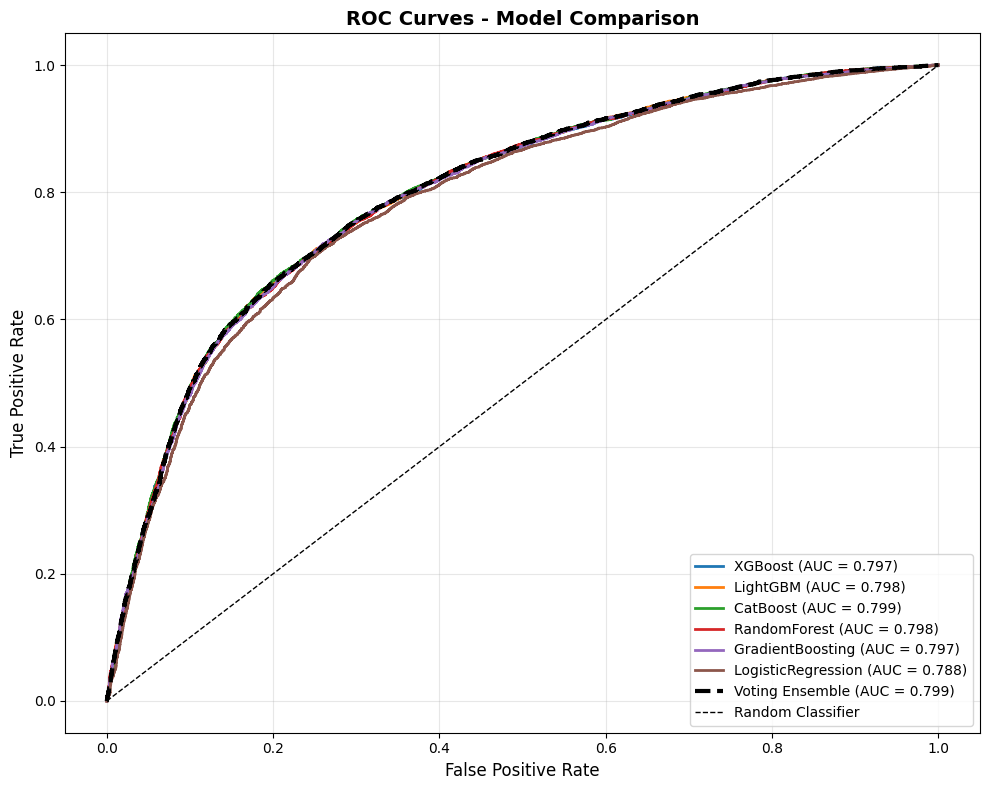

 ROC curves plotted!


In [20]:
plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

y_pred_proba_ens = voting_ensemble.predict_proba(X_test_scaled)[:, 1]
fpr_ens, tpr_ens, _ = roc_curve(y_test, y_pred_proba_ens)
roc_auc_ens = auc(fpr_ens, tpr_ens)
plt.plot(fpr_ens, tpr_ens, label=f'Voting Ensemble (AUC = {roc_auc_ens:.3f})',
         linewidth=3, linestyle='--', color='black')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(" ROC curves plotted!")

## 8. Explainability Techniques (XAI)


EXPLAINABILITY TECHNIQUE 1: SHAP (SHapley Additive exPlanations)

Computing SHAP values for XGBoost model...
SHAP values computed!


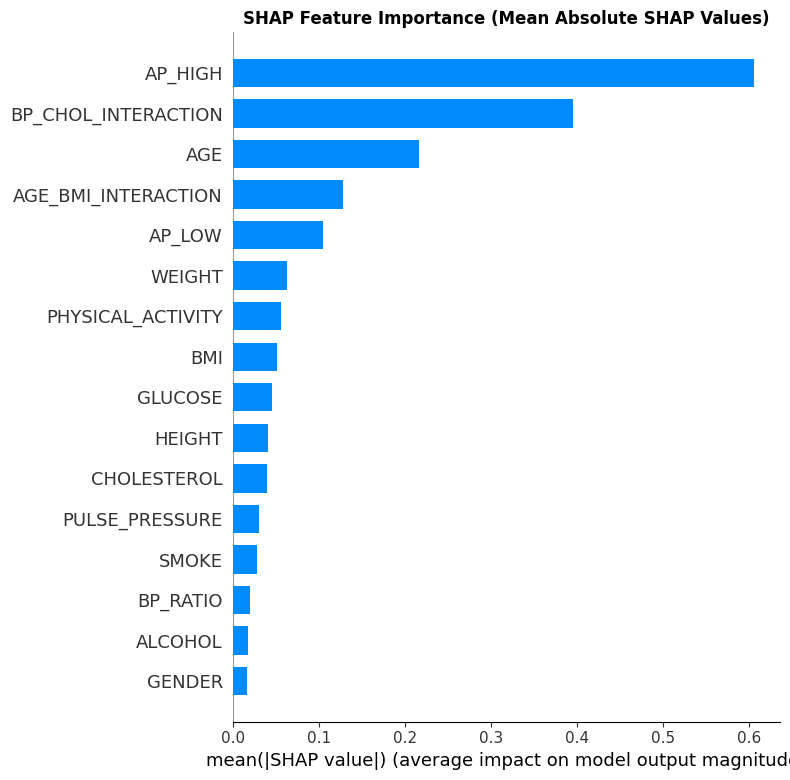

SHAP summary plot saved!


In [21]:
print("="*80)
print("EXPLAINABILITY TECHNIQUE 1: SHAP (SHapley Additive exPlanations)")
print("="*80)

print("\nComputing SHAP values for XGBoost model...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled.iloc[:500])

print("SHAP values computed!")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled.iloc[:500], plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Mean Absolute SHAP Values)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=100, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved!")

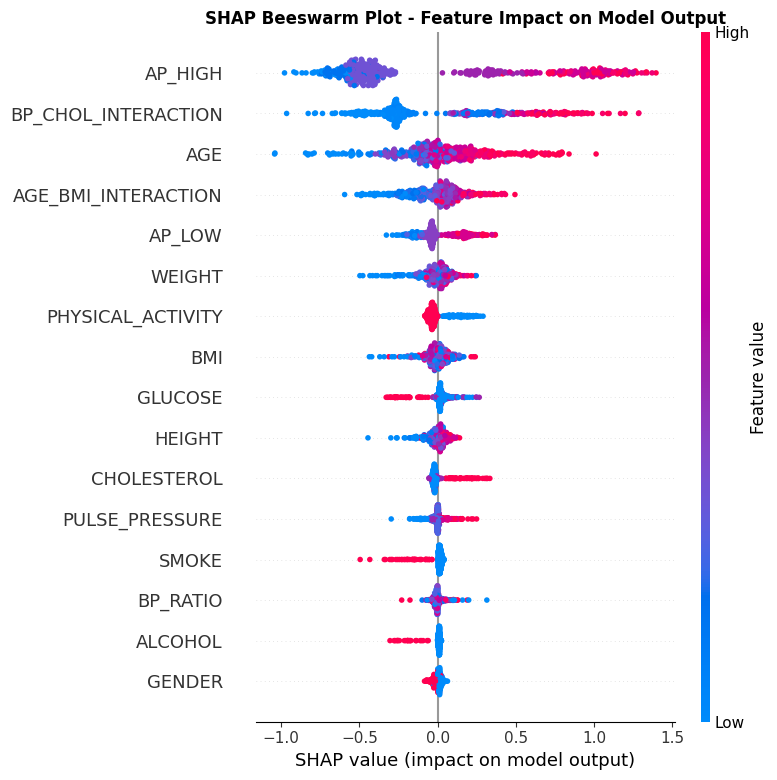

SHAP beeswarm plot saved!


In [22]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled.iloc[:500], show=False)
plt.title('SHAP Beeswarm Plot - Feature Impact on Model Output', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=100, bbox_inches='tight')
plt.show()
print("SHAP beeswarm plot saved!")


SHAP Local Explanation (For individual predictions):

Case 1: Positive (Disease Present) - Index 25687


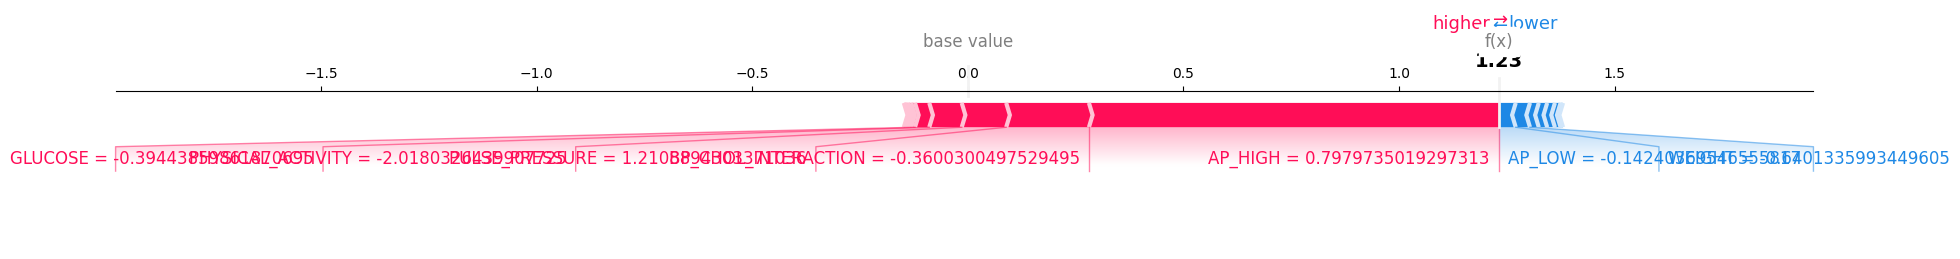


Case 2: Negative (No Disease) - Index 34600


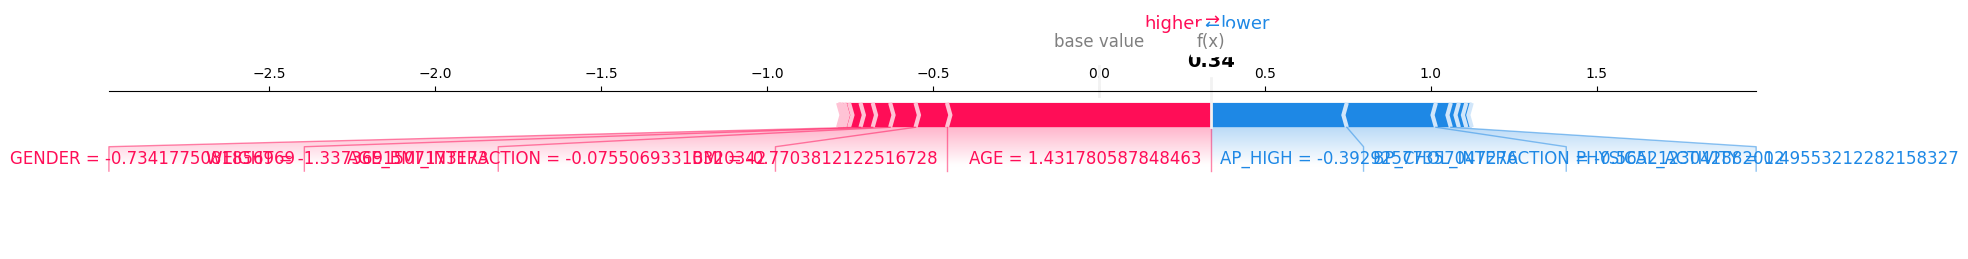

 SHAP local explanations saved!


In [23]:
print("\nSHAP Local Explanation (For individual predictions):\n")

positive_idx = (y_test == 1).idxmax()
negative_idx = (y_test == 0).idxmax()

print(f"Case 1: Positive (Disease Present) - Index {positive_idx}")
shap.force_plot(explainer.expected_value,
                shap_values[X_test_scaled.index.get_loc(positive_idx)],
                X_test_scaled.loc[positive_idx],
                matplotlib=True, show=False)
plt.tight_layout()
plt.savefig('shap_force_plot_positive.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nCase 2: Negative (No Disease) - Index {negative_idx}")
shap.force_plot(explainer.expected_value,
                shap_values[X_test_scaled.index.get_loc(negative_idx)],
                X_test_scaled.loc[negative_idx],
                matplotlib=True, show=False)
plt.tight_layout()
plt.savefig('shap_force_plot_negative.png', dpi=100, bbox_inches='tight')
plt.show()

print(" SHAP local explanations saved!")

In [24]:
print("\n" + "="*80)
print("EXPLAINABILITY TECHNIQUE 2: LIME (Local Interpretable Model-agnostic Explanations)")
print("="*80)

print("\nInitializing LIME explainer...")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_balanced.values,
    feature_names=feature_names,
    class_names=['No Disease', 'Disease'],
    mode='classification',
    random_state=42
)

print(" LIME explainer initialized!")

print("\nGenerating LIME explanations for sample predictions...\n")

for sample_idx in [positive_idx, negative_idx]:
    sample_data = X_test_scaled.loc[sample_idx].values.reshape(1, -1)
    prediction = xgb_model.predict_proba(sample_data)[0]

    exp = lime_explainer.explain_instance(
        data_row=sample_data[0],
        predict_fn=xgb_model.predict_proba,
        num_features=10
    )

    if (y_test.loc[sample_idx] == 1):
        exp.save_to_file(f'lime_explanation_positive_{sample_idx}.html')
        print(f" LIME explanation saved for positive case (Index {sample_idx})")
    else:
        exp.save_to_file(f'lime_explanation_negative_{sample_idx}.html')
        print(f" LIME explanation saved for negative case (Index {sample_idx})")

    print(f"\nPrediction for index {sample_idx}:")
    print(f"  Probability of Disease: {prediction[1]:.4f}")
    print(f"  Top contributing features:")
    for feature, weight in exp.as_list():
        print(f"    {feature}: {weight:.4f}")


EXPLAINABILITY TECHNIQUE 2: LIME (Local Interpretable Model-agnostic Explanations)

Initializing LIME explainer...
 LIME explainer initialized!

Generating LIME explanations for sample predictions...

 LIME explanation saved for positive case (Index 25687)

Prediction for index 25687:
  Probability of Disease: 0.7742
  Top contributing features:
    -0.39 < AP_HIGH <= 0.80: 0.1328
    AP_LOW <= -0.14: -0.0733
    SMOKE <= -0.31: 0.0519
    ALCOHOL <= -0.24: 0.0469
    WEIGHT <= -0.64: -0.0448
    CHOLESTEROL <= -0.54: -0.0304
    GLUCOSE <= -0.39: 0.0267
    HEIGHT <= -0.66: -0.0191
    -0.12 < AGE_BMI_INTERACTION <= 0.51: 0.0152
    -0.46 < BP_CHOL_INTERACTION <= 0.26: -0.0138
 LIME explanation saved for negative case (Index 34600)

Prediction for index 34600:
  Probability of Disease: 0.5838
  Top contributing features:
    AP_HIGH <= -0.39: -0.2027
    BP_CHOL_INTERACTION <= -0.57: -0.1317
    AP_LOW <= -0.14: -0.0741
    AGE > 0.69: 0.0739
    WEIGHT <= -0.64: -0.0375
    SMOKE <=


EXPLAINABILITY TECHNIQUE 3: PERMUTATION IMPORTANCE

Computing permutation importance for XGBoost model...

Permutation Importance Ranking:
            Feature  Importance      Std
            AP_HIGH    0.088268 0.003022
BP_CHOL_INTERACTION    0.037566 0.002065
                AGE    0.009159 0.001367
AGE_BMI_INTERACTION    0.004485 0.000903
             AP_LOW    0.002544 0.000587
                BMI    0.002224 0.001162
  PHYSICAL_ACTIVITY    0.001854 0.000408
             WEIGHT    0.001570 0.001190
        CHOLESTEROL    0.001403 0.000886
     PULSE_PRESSURE    0.001054 0.000766
              SMOKE    0.000676 0.000649
            ALCOHOL    0.000545 0.000385
             HEIGHT    0.000523 0.000608
            GLUCOSE    0.000363 0.000580
           BP_RATIO    0.000363 0.000573
             GENDER    0.000189 0.000291


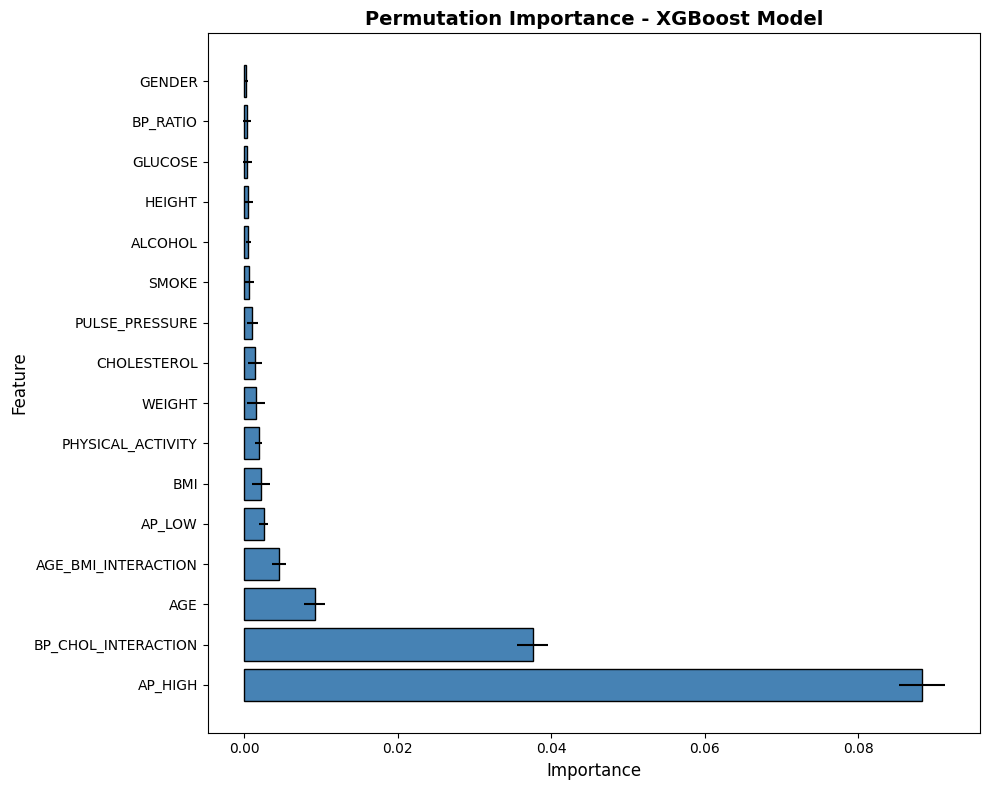


 Permutation importance computed and visualized!


In [25]:
print("\n" + "="*80)
print("EXPLAINABILITY TECHNIQUE 3: PERMUTATION IMPORTANCE")
print("="*80)

print("\nComputing permutation importance for XGBoost model...")

perm_importance = permutation_importance(
    xgb_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print("\nPermutation Importance Ranking:")
print(perm_importance_df.to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(perm_importance_df['Feature'], perm_importance_df['Importance'],
         xerr=perm_importance_df['Std'], color='steelblue', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Permutation Importance - XGBoost Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n Permutation importance computed and visualized!")


EXPLAINABILITY TECHNIQUE 4: PARTIAL DEPENDENCE PLOTS (PDP)

Computing partial dependence for top features...


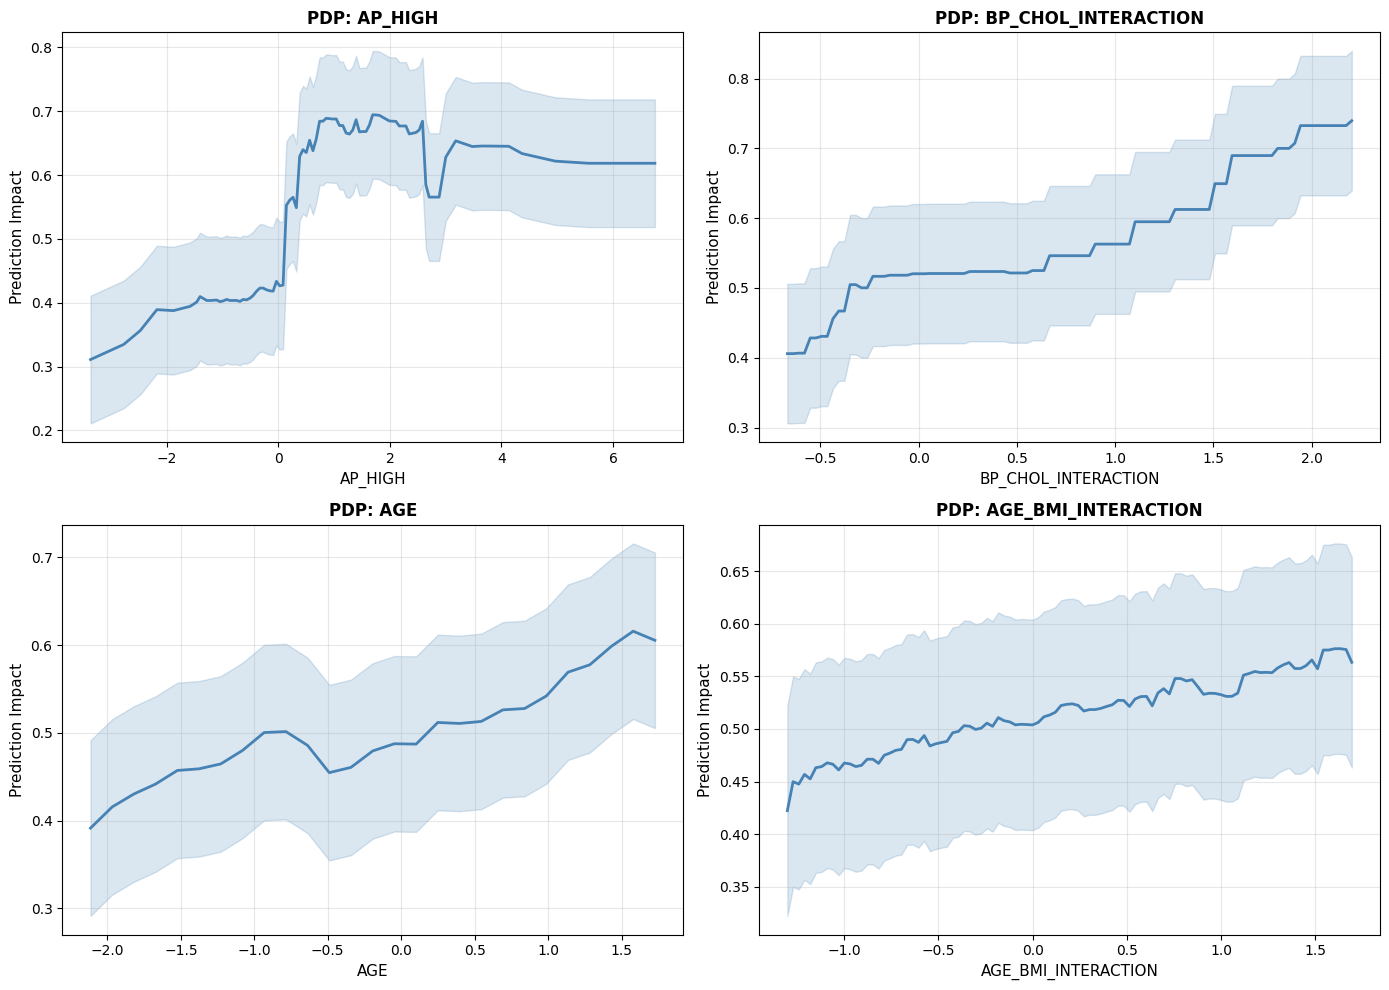

 Partial Dependence Plots generated!


In [27]:
print("\n" + "="*80)
print("EXPLAINABILITY TECHNIQUE 4: PARTIAL DEPENDENCE PLOTS (PDP)")
print("="*80)

print("\nComputing partial dependence for top features...")

top_features_idx = [feature_names.index(f) for f in perm_importance_df['Feature'].head(4).tolist()]
top_features = perm_importance_df['Feature'].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (feature_idx, feature_name) in enumerate(zip(top_features_idx, top_features)):
    pd_result = partial_dependence(xgb_model, X_test_scaled, [feature_idx])

    axes[idx].plot(pd_result['grid_values'][0], pd_result['average'][0],
                   linewidth=2, color='steelblue')
    axes[idx].fill_between(pd_result['grid_values'][0],
                           pd_result['average'][0] - 0.1,
                           pd_result['average'][0] + 0.1,
                           alpha=0.2, color='steelblue')
    axes[idx].set_xlabel(feature_name, fontsize=11)
    axes[idx].set_ylabel('Prediction Impact', fontsize=11)
    axes[idx].set_title(f'PDP: {feature_name}', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('partial_dependence_plots.png', dpi=100, bbox_inches='tight')
plt.show()

print(" Partial Dependence Plots generated!")